In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')

weather = pd.read_csv('../data/raw/weather_daily.csv', parse_dates=['date'], na_values=['NA',''])
soil    = pd.read_csv('../data/raw/soil_sensor_data.csv', parse_dates=['timestamp'], na_values=['NA',''])
params  = pd.read_csv('../data/raw/crop_zone_parameters.csv')

print(' WEATHER ')
print(weather.shape)
print(weather.head())

print('\n SOIL SENSORS ')
print(soil.shape)
print(soil.head())

print('\nCROP PARAMETERS ')
print(params)

 WEATHER 
(30, 6)
        date  rainfall_mm  temperature_c  humidity_pct  wind_speed_mps  \
0 2026-03-01          3.2           23.8          69.7            2.28   
1 2026-03-02          2.2           25.9          62.0            1.62   
2 2026-03-03          3.0           26.8          64.4            2.11   
3 2026-03-04          1.6           27.0          64.6            2.09   
4 2026-03-05         23.7           26.6          61.0            1.36   

   solar_index  
0         0.78  
1         0.71  
2         0.75  
3         0.58  
4         0.62  

 SOIL SENSORS 
(90, 7)
            timestamp zone_id  soil_moisture_pct  tank_level_liters  \
0 2026-03-01 12:00:00  Zone_A               33.2               4829   
1 2026-03-01 12:00:00  Zone_B               34.7               4728   
2 2026-03-01 12:00:00  Zone_C               28.2               4515   
3 2026-03-02 12:00:00  Zone_A               36.1               4757   
4 2026-03-02 12:00:00  Zone_B               32.0        

In [5]:
def compute_et(T, W, Solar, H):
    """
    Compute daily evapotranspiration (ET).
    
    Parameters:
        T     : temperature (°C)
        W     : wind speed (m/s)
        Solar : solar index (0-1)
        H     : humidity (%)
    
    Returns:
        ET in mm/day — always >= 0
    """
    return max(0.0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)


def water_balance(S, R, I, ET, D):
    """
    Compute next day soil moisture using water balance equation.
    S(t+1) = S(t) + R + I - ET - D
    
    Parameters:
        S  : current soil moisture (%)
        R  : rainfall (mm)
        I  : irrigation applied (mm)
        ET : evapotranspiration (mm)
        D  : drainage (mm)
    
    Returns:
        Next day soil moisture (%)
    """
    return S + R + I - ET - D


# Test with a typical Kenyan March day
et = compute_et(T=25, W=2.0, Solar=0.7, H=65)
print(f"ET for typical March day: {et:.3f} mm/day")

s_next = water_balance(S=33, R=5, I=0, ET=et, D=0)
print(f"Next day soil moisture  : {s_next:.3f} %")

ET for typical March day: 3.755 mm/day
Next day soil moisture  : 34.245 %


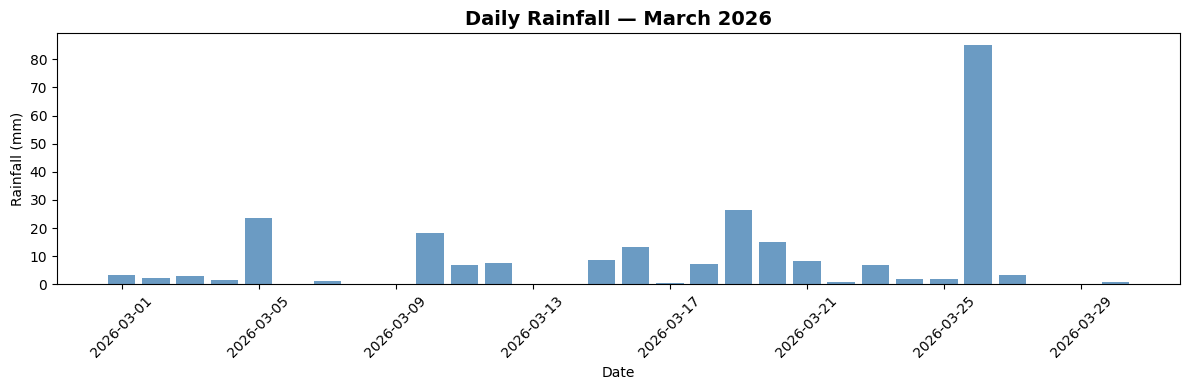

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(weather['date'], weather['rainfall_mm'], color='steelblue', alpha=0.8)

ax.set_title('Daily Rainfall — March 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Problem Statement

In Nakuru County, smallholder farmers face one of the most persistent 
challenges in Kenyan agriculture not knowing exactly when and how much to 
irrigate. Rainfall in the region is increasingly unpredictable, with prolonged 
dry spells interrupted by sudden heavy downpours that the soil cannot 
always absorb. A farmer growing tomatoes, kale, and maize across three 
small plots cannot afford to guess. Over-irrigating wastes water and 
drives up pumping costs. Under-irrigating causes crop stress that 
silently reduces yields before any visible damage appears.
The main problem is that irrigation decisions are currently made by 
intuition rather than data. A farmer walks the field, checks the soil 
by hand, and makes a judgment call. This works in good seasons. In a 
dry March or an unusually hot week, it fails and the losses fall 
entirely on the farmer.That is where Hydrosense Kenya comes in.
HydroSense-Kenya is a scientific computing system designed to change 
this. It combines daily weather observations:rainfall, temperature, 
humidity, wind speed, and solar radiation, with soil moisture sensor 
readings from three crop zones to model the daily water balance of 
each zone. The main question it answers is: given today's weather 
and current soil moisture, how much irrigation does each zone need 
to avoid stress while minimizing water use?
The system works with three datasets collected over March 2026:
- Weather data: 30 days of daily observations (6 variables)
- Soil sensor data: daily readings across Zone A (tomato, 120m^2), 
  Zone B (kale, 90m^2), and Zone C (maize, 180m^2)
- Crop zone parameters: minimum moisture thresholds, field capacity, 
  and drainage coefficients per zone
To answer the irrigation question, the system implements several 
numerical methods from scratch. Evapotranspiration (ET) that is the water 
lost from soil and crops to the atmosphere, it is computed daily using 
temperature, wind, solar index and humidity. Root finding methods 
(bisection, Newton-Raphson, secant) are used to find the exact 
irrigation amount that brings each zone to its target moisture. 
Euler and Runge-Kutta methods simulate how soil moisture evolves 
over 30 days. Monte Carlo simulation quantifies the risk of water 
shortage across 1000 possible rainfall scenarios.

What this system does not do: it does not replace the farmer's 
judgment entirely. It does not account for crop disease, soil type 
variation within a zone or intraday weather changes. The ET formula 
used is a simplified empirical model. Results should be treated as decision support, not 
absolute prescriptions.